<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Course: Advanced Machine Learning</p>

<p style="text-align: center;"> Course code: 203238427 </p>

<p style="text-align: center;"> Group: 01 </p>

<p style="text-align: center;"> Phase 4 - Time series</p>

<p style="text-align: center;">  Presented by: Jeronimo Ramos Ruiz</p>

<p style="text-align: center;">  Tutor: Rafael Gaitán Ospina </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> Medellin, April 2026 </p>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

# Load dataset

For the development of this work, the data set containing the monthly milk production per cow from January 1962 to December 1975 was selected. It is assumed that the unit of measurement corresponds to the liters measured after one day of production.

In [3]:
# We load the data from the GitHub repository to avoid problems
# with importing it if working with a Colab kernel

path = 'https://raw.githubusercontent.com/Jero2110/Advanced-ML_Phase-04/refs/heads/main/analysis/data/monthly-milk-production-pounds-p(in).csv'


df = pd.read_csv(path, parse_dates=['Month'], index_col='Month')
df = df.rename(columns={'Monthly milk production: pounds per cow. Jan 62 ? Dec 75': 'Milk_production'})

df.tail()


,Milk_production
Month,
1975-10,827.0
1975-11,797.0
1975-12,843.0
NaN,NaN
Monthly milk production: pounds per cow. Jan 62 ? Dec 75,NaN


In many cases, when importing data from a CSV file, some records in the last few rows may not be relevant for analysis. Therefore, they will be removed from the working data frame.

In [4]:
df_clean = df.dropna()

df_clean.index = pd.to_datetime(df_clean.index)

df_clean.tail()

,Milk_production
Month,
1975-08-01,858.0
1975-09-01,817.0
1975-10-01,827.0
1975-11-01,797.0
1975-12-01,843.0


Once these rows have been removed, we will proceed to identify possible missing data and outliers with the help of the boxplot:

In [5]:
# First we will identify the null values

rows = df_clean.shape[0]
null_rows = df_clean.isna().sum()

print('---'*30)
print(f'The data set has {rows} rows, of which {null_rows} have null values')
print('---'*30)

------------------------------------------------------------------------------------------
The data set has 168 rows, of which Milk_production    0
dtype: int64 have null values
------------------------------------------------------------------------------------------


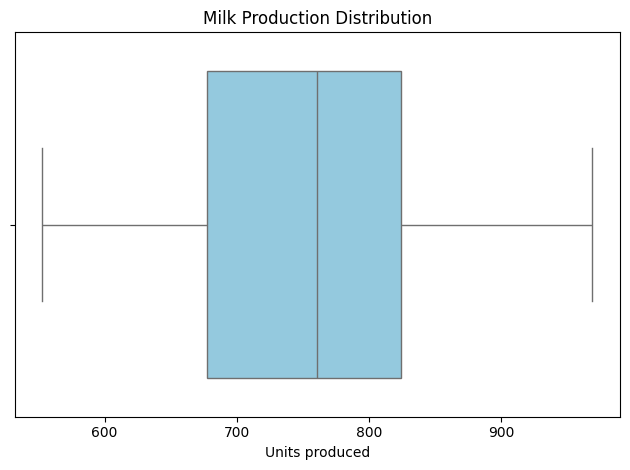

In [6]:
plt.plot(figsize=(10, 10))

# Box plot (to see outliers and distribution)
sns.boxplot(x=df_clean['Milk_production'], color='skyblue')
plt.title('Milk Production Distribution')
plt.xlabel('Units produced')

plt.tight_layout()
plt.show()

As can be seen in the box plot, there do not appear to be any outliers within the selected dataset, as they all remain within the interquartile range. Therefore, we can continue with the analysis with the certainty that we have no outliers.

However, since the data covers all 12 months of each year, the records will be counted by year to identify any missing values ​​that need to be corrected.

In [7]:
records_per_year = df_clean.index.year.value_counts().sort_index()

print('---'*30)
print(f'{records_per_year}')
print('---'*30)

------------------------------------------------------------------------------------------
Month
1962    12
1963    12
1964    12
1965    12
1966    12
1967    12
1968    12
1969    12
1970    12
1971    12
1972    12
1973    12
1974    12
1975    12
Name: count, dtype: int64
------------------------------------------------------------------------------------------


As can be seen in the table above, there does not appear to be any missing data, as all years of study seem to contain information for each of the months of study.

# Step 1

Now that we know the information is clean, we will proceed to identify, using a line graph, the possible presence of trend and seasonality.

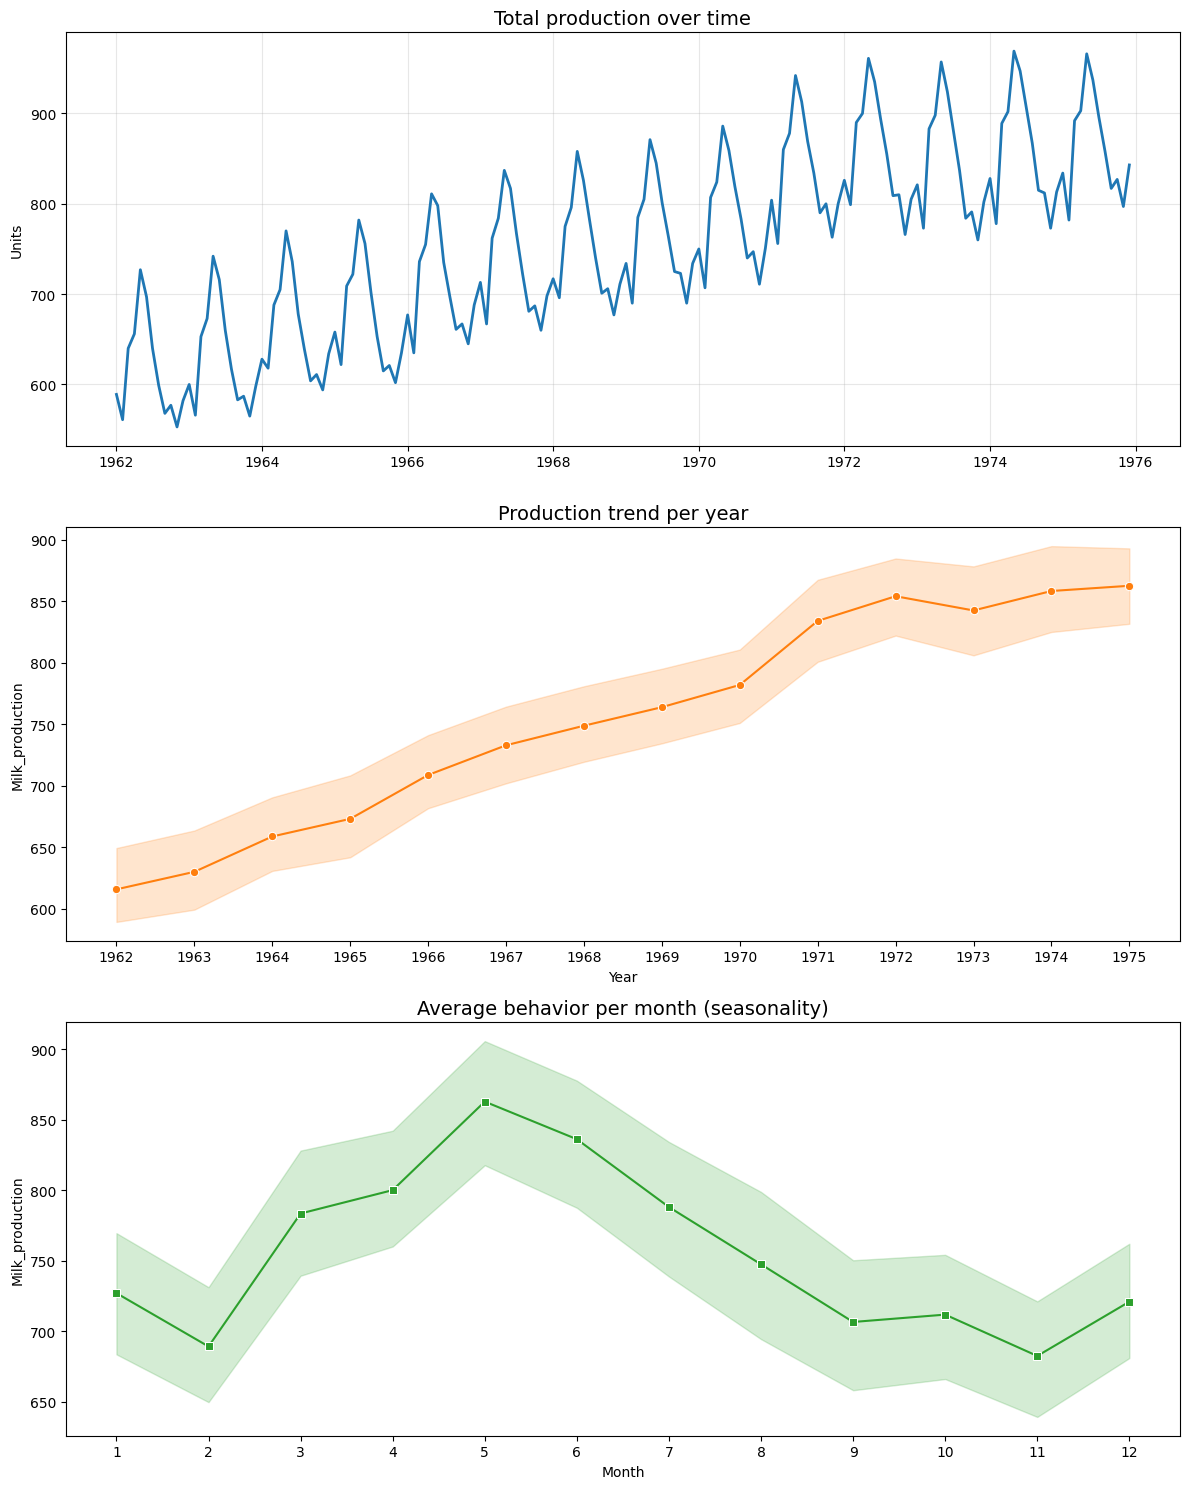

In [9]:
# First wwe create the columns with the information of the day, month and year 
# Crear las nuevas columnas
df_clean.loc[:, 'Year'] = df_clean.index.year
df_clean.loc[:,'Month'] = df_clean.index.month

# Line graph (to visualize monthly production over time in different times)
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Chart 1: Complete time series (solid line)
axes[0].plot(df_clean.index, df_clean['Milk_production'], color='tab:blue', linewidth=2)
axes[0].set_title('Total production over time', fontsize=14)
axes[0].set_ylabel('Units')
axes[0].grid(True, alpha=0.3)

# Chart 2: Variation by Year (Using the 'Year' column)
sns.lineplot(data=df_clean, x='Year', y='Milk_production', ax=axes[1], color='tab:orange', marker='o')
axes[1].set_title('Production trend per year', fontsize=14)
axes[1].set_xticks(df_clean['Year'].unique())

# Chart 3: Seasonality by month (using the 'Month' column)
sns.lineplot(data=df_clean, x='Month', y='Milk_production', ax=axes[2], color='tab:green', marker='s')
axes[2].set_title('Average behavior per month (seasonality)', fontsize=14)
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()


In the graphs above we can observe the normal behavior of the data series (first graph with blue lines), the possible trend of the data over the years (second graph with orange lines) and the possible presence of temporality through the months of study (last graph in green).

The first graph shows a clear upward trend in the data, which is confirmed in the second. This indicates that monthly milk production is increasing over time, either due to an increase in the number of cattle or improvements in milk extraction and feeding technologies. On the other hand, a recurring pattern is observed in the middle of the year, as confirmed by the third graph. It appears that milk production peaks in May and then declines throughout the year. This could be related to the seasons in some countries, where cold weather influences food production and vegetation, as well as the ability of cows to produce milk, since they use all their energy to survive the cold. Meanwhile, between April and July, the weather is suitable for food production and there is not as much stress to affect the animals' milk production.

# Step 2

Now that we understand the behavior of the time series, we can see that there are some properties that can be difficult to analyze when using a forecasting method such as ARIMA or LSTM.

To apply a predictive model like ARIMA, the series must be stationary, meaning its statistical properties do not change over time. This allows the model to focus on understanding the internal structure of the data rather than on predictable and repetitive variables (trends and cycles), resulting in a more reliable model.

With this in mind, we aim for the mean and variance to be constant. On one hand, the mean indicates the trend that may exist in the data, meaning it changes depending on the observation point, making it difficult for the model to predict the future if the baseline is constantly changing. On the other hand, the variance indicates seasonality or patterns that repeat at regular intervals. These patterns make the variance behave in a predictable, but somewhat unstable, way.

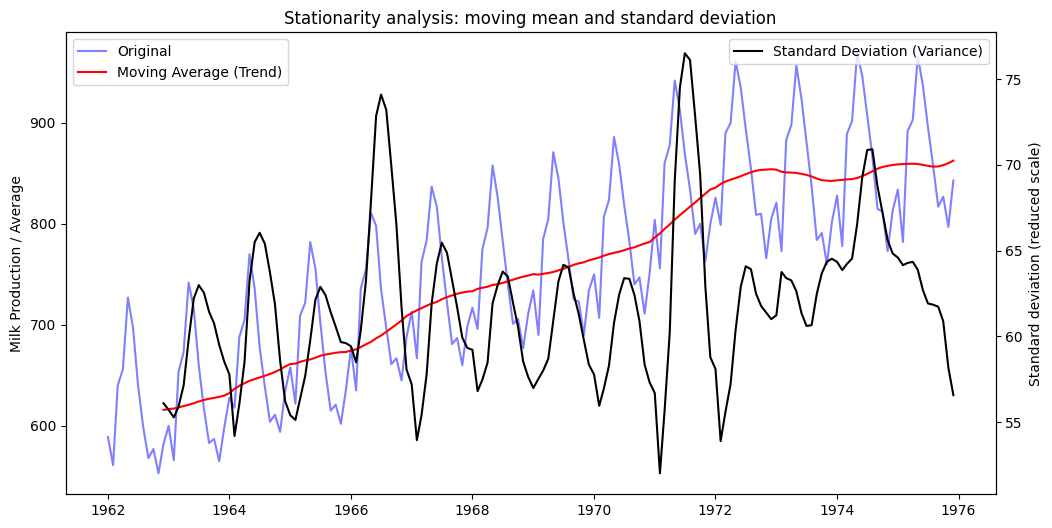

In [19]:
# We want to check if the time series is stationary, which means that all its statistical properties are constant over time.
rolmean = df_clean['Milk_production'].rolling(window=12).mean()
rolstd = df_clean['Milk_production'].rolling(window=12).std()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df_clean['Milk_production'], color='blue', label='Original', alpha=0.5)
ax1.plot(rolmean, color='red', label='Moving Average (Trend)')
ax1.set_ylabel('Milk Production / Average')
ax1.legend(loc='upper left')

# We create the second axis that shares the same X-axis.
ax2 = ax1.twinx()
plt.plot(rolstd, color='black', label='Standard Deviation (Variance)')
ax2.set_ylabel('Standard deviation (reduced scale)')
plt.legend(loc='upper right')


plt.title('Stationarity analysis: moving mean and standard deviation')
plt.show()

In the graph above, the blue line represents the initial time series with a clear trend and marked seasonality, occurring approximately every 12 months. This trend is confirmed by the increasing behavior of the mean, represented by the red line, and the variance shows production peaks close to the identified time. However, production peaks are also observed around the years 1966, 1971, and 1972. These records could indicate special conditions in milk production, such as extreme weather, difficulties in feeding the animals, or, conversely, good production due to ideal conditions.

<Figure size 1200x400 with 0 Axes>

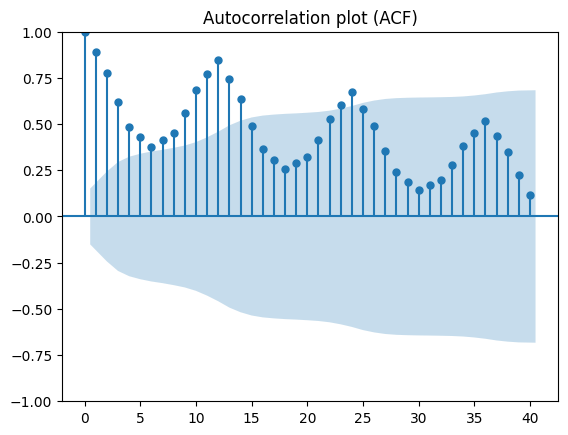

In [11]:
plt.figure(figsize=(12, 4))
plot_acf(df_clean['Milk_production'], lags=40)
plt.title('Autocorrelation plot (ACF)')
plt.show()

Using the Autocorrelation Factor (ACF) chart, we can observe that the bars remain high and outside the blue shaded area (the confidence interval) for many lags. This confirms that past values ​​have a strong influence on current values, indicating a trend.

On the other hand, the "wave" or peak pattern is clearly repeating. There is a very defined peak near lag 12 and another at lag 24. This indicates a 12-month seasonal cycle. In other words, this suggests that what happened in January of last year is an excellent predictor of what will happen in January of this year.

In [12]:
print('Resultados de la prueba de Dickey-Fuller:')
dftest = adfuller(df_clean['Milk_production'], autolag='AIC')

dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key, value in dftest[4].items():
    dfoutput[f'Critical Value ({key})'] = value

print(dfoutput)


Resultados de la prueba de Dickey-Fuller:
Test Statistic                  -1.303812
p-value                          0.627427
#Lags Used                      13.000000
Number of Observations Used    154.000000
Critical Value (1%)             -3.473543
Critical Value (5%)             -2.880498
Critical Value (10%)            -2.576878
dtype: float64


Finally, using the Dickey-Fuller test, which aims to determine if the data are stationary (constant mean and variance), we can observe, by analyzing the p-value > 0.5, that the null hypothesis cannot be rejected.

Therefore, based on all the evidence presented above, it is possible to conclude that the series is NOT stationary. With this in mind, it is necessary to apply a differentiation.

## Differentiation

The differentiation consists of subtracting the previous value from the current value to eliminate the trend, as well as subtracting the value from the same month of the previous year to eliminate seasonality.

Since seasonality was identified in previous steps, it is necessary to apply ordinary differentiating, where the current month is subtracted from the previous month to eliminate the trend. Subsequently, the current month is subtracted from the same month of the previous year to eliminate seasonality.

In [ ]:
# 1. Simple difference (eliminates the trend)
df_clean['diff_1'] = df_clean['Milk_production'].diff()

# 2. Seasonal difference over the simple one (eliminates seasonality)
df_clean['diff_12'] = df_clean['diff_1'].diff(12)

# Remove NaN values ​​generated by differentiation
df_estacionario = df_clean.dropna()


/tmp/ipykernel_3851/1624943248.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['diff_1'] = df_clean['Milk_production'].diff()
/tmp/ipykernel_3851/1624943248.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['diff_12'] = df_clean['diff_1'].diff(12)


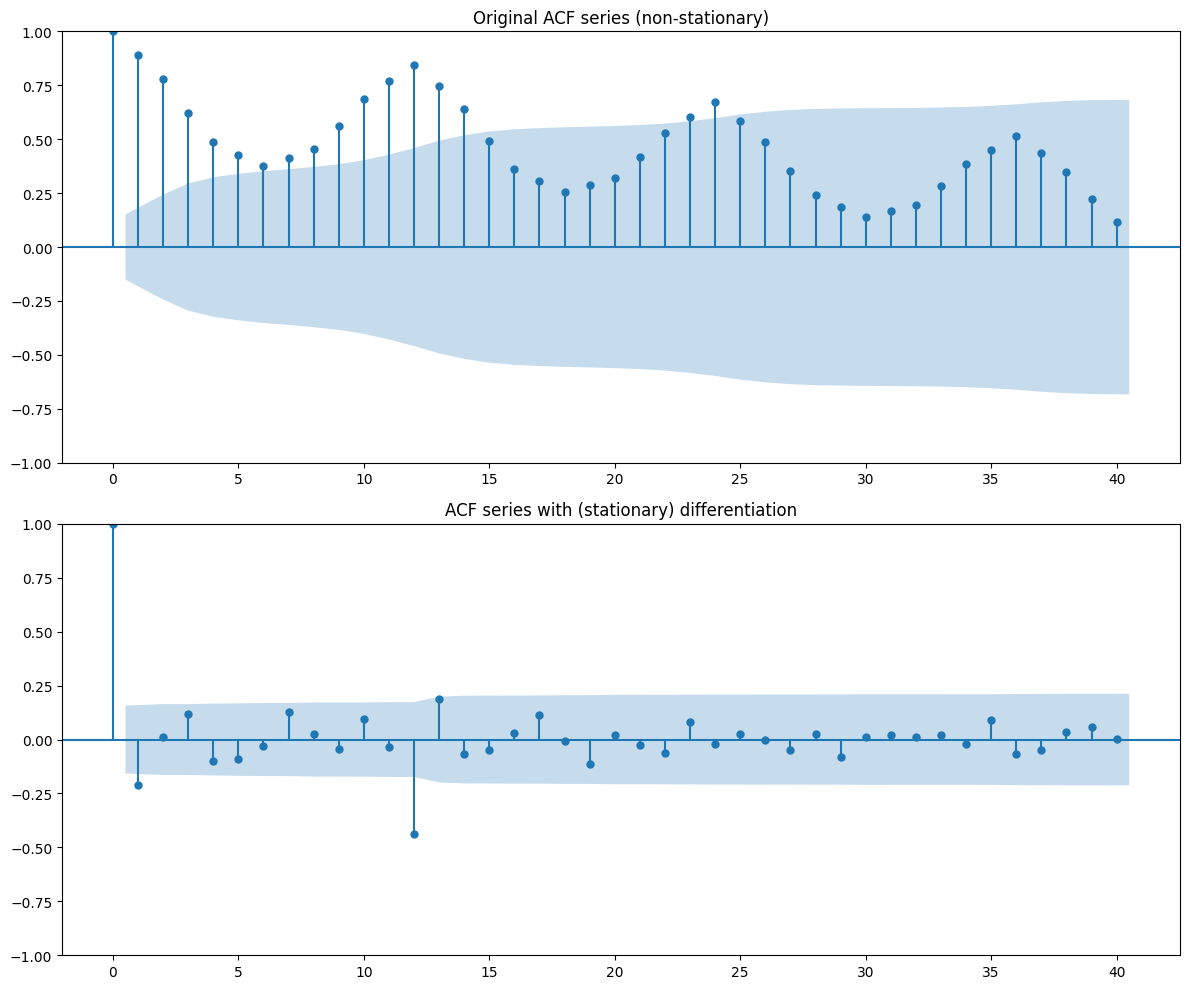

In [14]:
# Visualization and comparison

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ACF from the original series
plot_acf(df_clean['Milk_production'], ax=axes[0], lags=40)
axes[0].set_title('Original ACF series (non-stationary)')

# ACF series with double differentiation
plot_acf(df_estacionario['diff_12'], ax=axes[1], lags=40)
axes[1].set_title('ACF series with (stationary) differentiation')

plt.tight_layout()
plt.show()


In [16]:
resultado = adfuller(df_estacionario['diff_12'])
print(f'p-value after differentiating: {resultado[1]}')

if resultado[1] <= 0.05:
    print("Success! The series is now stationary.")
else:
    print("The series is not yet stationary; it may require another transformation.")


p-value after differentiating: 1.865423431878848e-05
Success! The series is now stationary.


## Data Splitting

In [17]:
# Calculate the cut-off point (70%)
train_size = int(len(df_estacionario) * 0.7)

# Divide the series (it is important to maintain the chronological order).
train = df_estacionario.iloc[:train_size]
test = df_estacionario.iloc[train_size:]

print(f"Total records: {len(df_estacionario)}")
print(f"Training records: {len(train)}")
print(f"Test records: {len(test)}")


Total records: 155
Training records: 108
Test records: 47


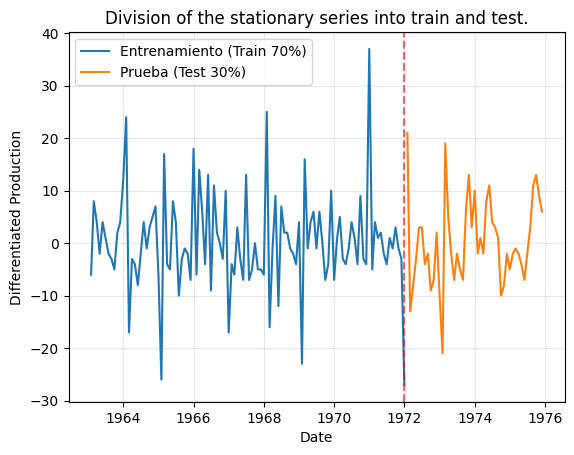

In [18]:
# Graph training data
plt.plot(train.index, train['diff_12'], label='Entrenamiento (Train 70%)', color='tab:blue')

# Graphic test data
plt.plot(test.index, test['diff_12'], label='Prueba (Test 30%)', color='tab:orange')

# Add a vertical line to mark the division.
plt.axvline(train.index[-1], color='red', linestyle='--', alpha=0.6)

plt.title('Division of the stationary series into train and test.')
plt.xlabel('Date')
plt.ylabel('Differentiated Production')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 3 - ARIMA Model

# Step 4 - Prophet Model

# Step 5 - LSTM neural network model

# References